# Locus Explorer

Given a locus, let's annotate all the alleles' motifs and copy numbers.

One thing we have to account for is ensuring that the motif/copy number of regions across alleles are consistent.

For example, we could have a CG motif in two places across a TRGT analyzed locus.

```
Reference   ATCATCG------AAAAAAACG------TT
Allele1     ATCATCGCGCGCGAAAAAAA--------TT
Allele2     ATCATCG------AAAAAAACGCGCGCGTT
```

While both alleles have +3 copies of the CG motif, where the expansion occurs differs.
In practice, most regions only have a single tandem repeat with a single motif, so the copy numbers of the motif is comparable across alleles. However, some more complex tandem repeats can have these differences. 

Therefore in addition to annotating the motifs and copy number for alleles, we'll perform an MSA to ensure that we're comparing comparable regions of alleles.

### Note

This uses the package truvari and pyabpoa (`python3 -m pip install truvari pyabpoa`)

In [1]:
import math
import pyabpoa
import truvari
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

import tdb


def translate_range(orig_sequence, msa_sequence, start, end):
    """
    Translate the a span over the original sequence to its coordinates in the msa space
    """
    orig_pos = 0
    msa_start = -1
    msa_end = -1
    
    for i, char in enumerate(msa_sequence):
        if char != '-':
            if orig_pos == start:
                msa_start = i
            if orig_pos == end:
                msa_end = i
                break
            orig_pos += 1
    
    # In case end is the last index in the nondashed sequence
    if msa_end == -1 and orig_pos == end:
        msa_end = len(msa_sequence)
    
    return msa_start, msa_end


def get_annotation(seq):
    """
    Call tr-solve on a sequence to annotate motifs/copynumber/purity return its motifs/coordinates
    returns a list of:
        motif, start, end, purity, copy_number
        
    Returns the 'canonical' motif such that the first nucleotide is the alphanumeric smallest
    e.g. GGC motif is 'rolled' to become a CGG motif
    """
    out = truvari.cmd_exe(f"echo {seq} | ./tr-solve")
    _, _, positions = out.stdout.strip().split('\t')
    ret = []
    for motif, start, end in map((lambda x: x.split('_')), positions.split(',')):
        start = int(start)
        end = int(end)
        span = end - start
        copynumber = span / len(motif)
        faux = (motif * math.ceil(copynumber))[:span]
        # Canonical motif
        motif = min([motif[i:] + motif[:i] for i in range(len(motif))])
        purity = truvari.seqsim(faux, seq[start:end])
        ret.append([motif, start, end, purity, copynumber])
    return ret


def run_msa(sequences):
    """
    Given a list of sequences, perform an MSA
    Returns the sequences in the same order, but with dashes from their alignment
    """
    # Could do some sorting here, but..
    aligner = pyabpoa.msa_aligner()
    aln_result = aligner.msa(sequences, False, True)
    return aln_result


# FMR1 Locus

For this analysis, we'll just look at the FMR1 Locus which starts around chrX:147911953


In [2]:
m_db = tdb.load_tdb("../JinEmory_TRGT_XY.tdb/", 
                    lfilters=[['chrom', "=", "chrX"],
                              ["start", ">", 147911653],
                              ["start", "<", 147912053]
                             ])

# And decode the sequence so we're just handling plain strings
m_db['allele']['sequence'] = m_db['allele']['sequence'].str.decode('utf8')

We'll start by making an MSA over all the sequences and then annotating all of the alleles. 

Ordering the alleles by their length will help the POA make a better MSA.

In [3]:
alleles = m_db['allele'].sort_values(by=['allele_length'])
msa_result = run_msa(list(alleles['sequence'])).msa_seq

parts = []
for msa_seq, row in zip(msa_result, alleles.iterrows()):
    _, row = row # unpack the row index from the row data
    
    anno = get_annotation(row["sequence"])
    for a in anno:
        # Translate the annotation to the msa space
        msa_start, msa_end = translate_range(row["sequence"], msa_seq, a[1], a[2])
        a.extend([msa_start, msa_end])

    anno = pd.DataFrame(anno, columns=["motif", "start", "end", "purity", "copynumber", "msa_start", "msa_end"])
    anno['allele_number'] = row['allele_number']
    
    parts.append(anno)
        

annotations = pd.concat(parts)

# Motif Distribution

We have over 1.2k motif annotations across the alleles. Let's look at the composition of these annotations.

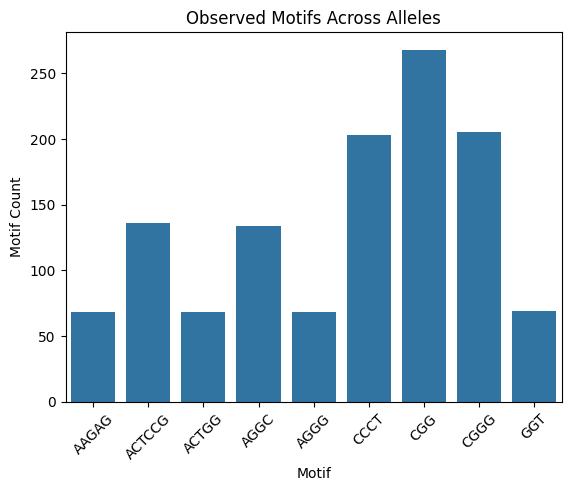

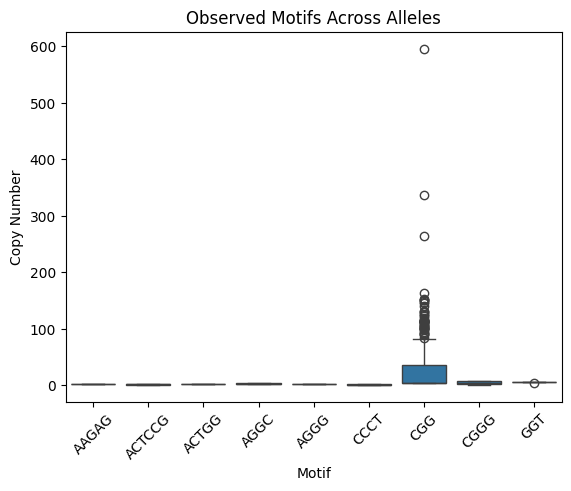

In [4]:
# Group by the motif
grp_motif = annotations.groupby(['motif'])
cnts = grp_motif['allele_number'].size()


order = sorted(list(cnts.index))
p = sb.barplot(cnts.reset_index(), 
               x="motif", y="allele_number", 
               order=order)
plt.xticks(rotation=45)
_ = p.set(title="Observed Motifs Across Alleles", 
          xlabel="Motif", ylabel="Motif Count")
plt.show()


p = sb.boxplot(data=annotations, 
               x="motif", y="copynumber", 
               order=order)
plt.xticks(rotation=45)
_ = p.set(title="Observed Motifs Across Alleles", 
          xlabel="Motif", ylabel="Copy Number")
plt.show()

CGG looks to be the variable motif in this region.

We expect 'blocks' of the MSA to have the same motif. So let's check the properties of annotations with shared MSA start/end boundaries


In [5]:
ac = annotations.groupby(['motif', 'msa_start', 'msa_end']).size().to_frame()
cn_mu = annotations.groupby(['motif', 'msa_start', 'msa_end'])['copynumber'].mean().to_frame().round(2)
cn_std = annotations.groupby(['motif', 'msa_start', 'msa_end'])['copynumber'].std().to_frame().round(2)

view = ac.join(cn_mu).join(cn_std, lsuffix="_")
view.columns = ["Allele Count", "CopyNumber Mean", "CopyNumber STD"]

view.reset_index().sort_values(by=["msa_start", "msa_end", "motif"]).reset_index(drop=True)

,motif,msa_start,msa_end,Allele Count,CopyNumber Mean,CopyNumber STD
0,CCCT,0,4,67,1.00,0.00
1,GGT,0,12,1,4.00,NaN
2,CGG,4,17,67,4.33,0.00
3,ACTCCG,12,23,1,1.83,NaN
4,ACTCCG,17,23,67,1.00,0.00
5,CGGG,23,179,67,7.50,0.00
6,CGG,23,1817,1,595.33,NaN
7,CGG,179,1816,67,102.49,49.03
8,CGGG,1817,1821,1,1.00,NaN
9,CGGG,1848,1856,68,2.00,0.00


The blocks which end at 1816 and 1817 are all CGG repeats and have some variability.

The rest of the blocks are stable (0 std) between all alleles.

Let's make a simple plot to view the CGG motifs in the MSA

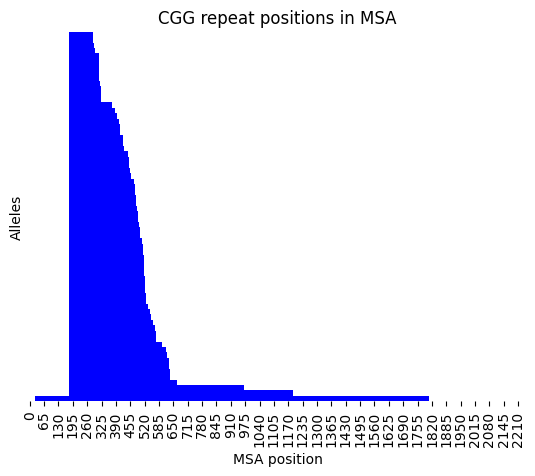

In [6]:
region = np.zeros((annotations['allele_number'].max() + 1, annotations['msa_end'].max()))

for _, row in annotations[annotations['msa_end'].isin([1816, 1817])].iterrows():
    start = row['msa_start']
    end = start + (row['end'] - row['start'])
    region[row['allele_number'], start: end] += 1

row_sums = np.sum(region, axis=1)
sorted_indices = np.argsort(row_sums)
region = region[sorted_indices]

binary_cmap = ListedColormap(['white', 'blue'])
p = sb.heatmap(region, cmap=binary_cmap, cbar=False)
_ = p.set(ylabel="Alleles", xlabel="MSA position", yticks=[], title="CGG repeat positions in MSA")

Let's look at the copy number and purity of this block across the alleles

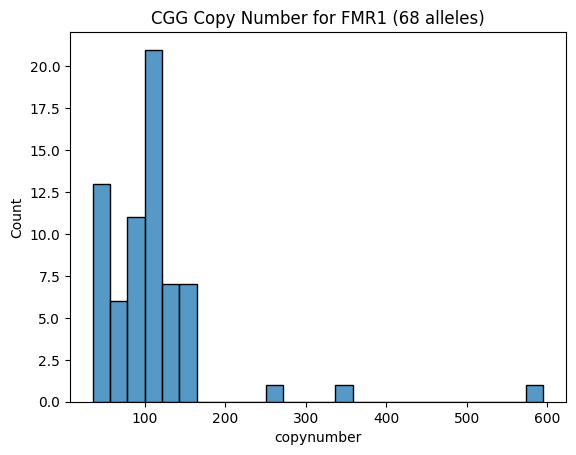

In [7]:
cgg_block = annotations[annotations['msa_end'].isin([1816, 1817])]
p = sb.histplot(data=cgg_block, x="copynumber")
n_alleles = len(cgg_block)
_ = p.set(title=f"CGG Copy Number for FMR1 ({n_alleles} alleles)") 

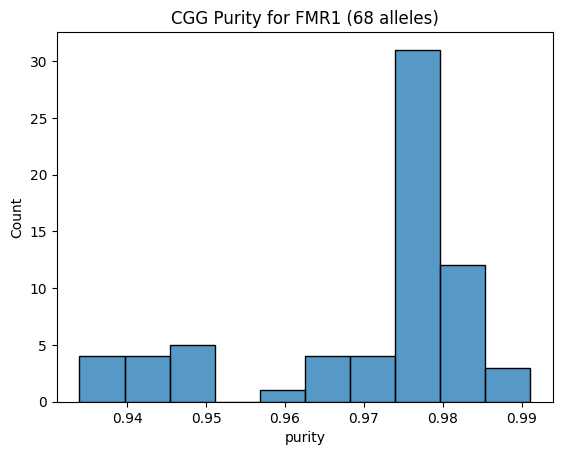

In [8]:
p = sb.histplot(data=cgg_block, x="purity")
n_alleles = len(cgg_block)
_ = p.set(title=f"CGG Purity for FMR1 ({n_alleles} alleles)") 

A side observation is that the higher copy number have a higher purity.

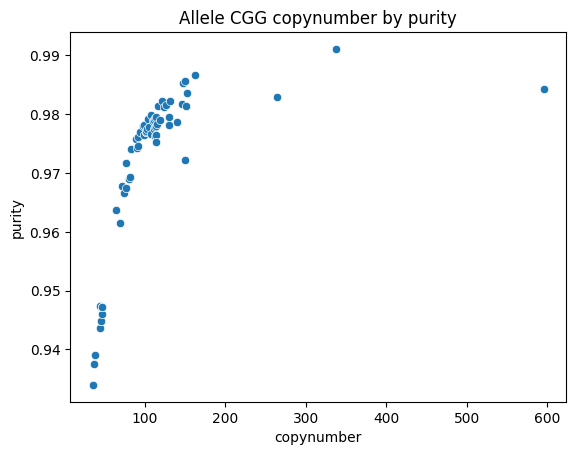

In [9]:
p = sb.scatterplot(data=cgg_block, x="copynumber", y="purity")
_ = p.set(title="Allele CGG copynumber by purity")

In [11]:
cgg_block['copynumber'].describe()

count     68.000000
mean     109.735294
std       77.073064
min       35.333333
25%       75.916667
50%      103.833333
75%      120.000000
max      595.333333
Name: copynumber, dtype: float64

Let's join these allele annotations to the samples and make a big table.

In [12]:
idx_anno = cgg_block.set_index(['allele_number'])
parts = []
for name, table in m_db['sample'].items():
    full_table = table.set_index(['allele_number']).join(idx_anno, how='left')
    full_table['sample'] = name
    parts.append(full_table)
    
full_sample_table = pd.concat(parts)

Since alleles can be shared, we haven't seen the full sample distribution of copy numbers, just the unique alleles, so let's look at that

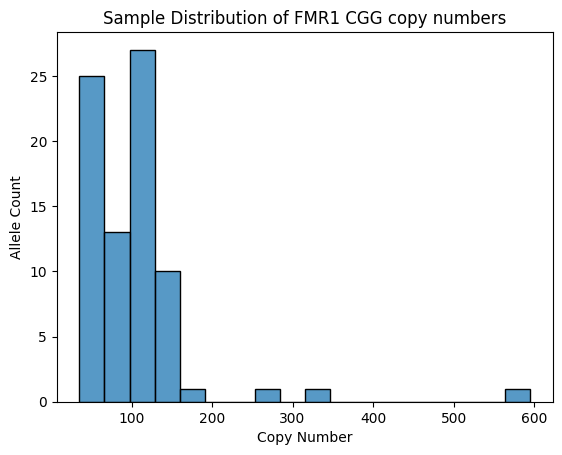

In [13]:
p = sb.histplot(data=full_sample_table, x="copynumber")
p.set(title="Sample Distribution of FMR1 CGG copy numbers", 
      xlabel="Copy Number", ylabel="Allele Count")
plt.show()

The samples with alleles having above ~210 copies of CGG seem interesting.

Let's look at which samples have them.

In [28]:
long_cn = full_sample_table[full_sample_table['copynumber'] >= 200]
long_cn[['sample', 'copynumber']]

,sample,copynumber
allele_number,,
28,FMR1-6-Brain-PFC,595.333333
17,FMR1-7-Brain-PFC,337.000000
11,FMR1-10-Brain-PFC,263.666667


We're only looking at the long alleles. Let's look at all the alleles in samples with long alleles so we can see the pair (if they're female).

In [29]:
full_sample_table['copynumber_interest'] = full_sample_table['sample'].isin(long_cn['sample'])

In [16]:
(full_sample_table[full_sample_table['copynumber_interest']]
    [['sample', 'copynumber', 'length_range_lower', 'length_range_upper', 'spanning_reads']])

,sample,copynumber,length_range_lower,length_range_upper,spanning_reads
allele_number,,,,,
28,FMR1-6-Brain-PFC,595.333333,2235,3008,2
17,FMR1-7-Brain-PFC,337.000000,1264,1626,9
11,FMR1-10-Brain-PFC,263.666667,753,6992,9


If an allele has a wider length upper/lower range, that could be indicative of potential mosaicism.

In [17]:
full_sample_table['length_range'] = full_sample_table['length_range_upper'] - full_sample_table['length_range_lower']

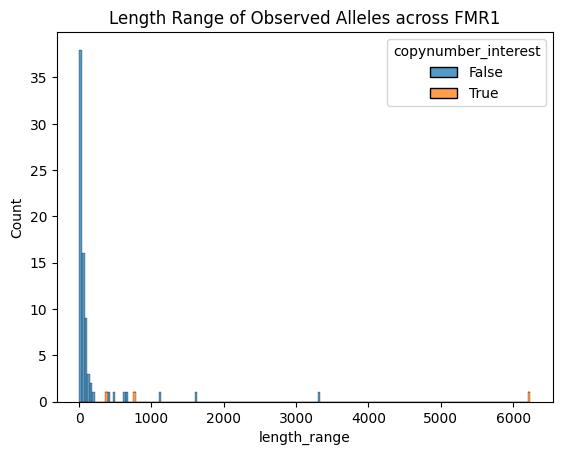

In [18]:
p = sb.histplot(data=full_sample_table, x="length_range", hue="copynumber_interest", multiple="stack")
_ = p.set(title="Length Range of Observed Alleles across FMR1")

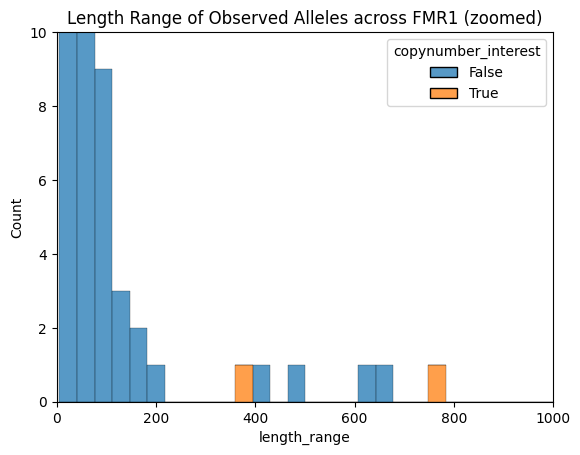

In [19]:
p = sb.histplot(data=full_sample_table, 
                x="length_range", 
                hue="copynumber_interest",
                multiple="stack")
_ = p.set(title="Length Range of Observed Alleles across FMR1 (zoomed)", 
          xlim=(0, 1000), ylim=(0,10))

While there seems to be some variability across nearly all alleles, there is a clear divide between those with more than ~215bp allele length range and those below.


Furthermore, not every sample with potential mosaicm was picked up by our copynumber threshold of 210. So we'll add a 'mosaic_interest' flag to generate our final classification of interesting alleles.

In [30]:
full_sample_table["mosaic_interest"] = full_sample_table['length_range'] >= 200
full_sample_table['interest'] = full_sample_table['mosaic_interest'] | full_sample_table['copynumber_interest']

In [31]:
s = full_sample_table[full_sample_table['interest']]['sample']
(full_sample_table[full_sample_table['sample'].isin(s)]
    [['sample', 'spanning_reads', 'copynumber', 'length_range', 'purity']]).round(2).sort_values(by="sample")

,sample,spanning_reads,copynumber,length_range,purity
allele_number,,,,,
7,C0125.001,17,140.33,397,0.98
34,C0209.002,18,44.33,9,0.94
40,C0209.002,11,146.33,1106,0.98
42,C0215.000,15,150.33,669,0.99
56,C0215.000,16,45.33,7,0.94
4,C0246.001,13,163.00,1629,0.99
34,C0342.000,20,44.33,9,0.94
66,C0342.000,11,151.67,491,0.98
11,FMR1-10-Brain-PFC,9,263.67,6239,0.98


# Summary

Of the `FMR1-*-Brain` samples, only PFC tissues have copynumber/mosaicism above the thresholds of +210 CGG copies and a length range ≥215. When considering the sample pairs for individuals, only FMR1-3, FMR1-4 have a difference between CEB and PFC. FMR1-1, FMR1-2, and FMR1-5 have copynumber/mosaicm below the thresholds for both CEB and PFC.

In [22]:
pd.set_option('display.max_rows', 500)
s = full_sample_table[full_sample_table['interest']]['sample']
(full_sample_table[~full_sample_table['sample'].isin(s)]
    [['sample', 'spanning_reads', 'copynumber', 'length_range', 'purity']]).round(2).sort_values(by="sample")

,sample,spanning_reads,copynumber,length_range,purity
allele_number,,,,,
1,C0050.008,16,91.00,31,0.98
62,C0053.003,25,44.33,5,0.95
37,C0053.003,15,107.33,113,0.98
29,C0063.004,20,124.00,149,0.98
0,C0065.000,25,35.33,7,0.93
45,C0065.000,13,89.33,17,0.98
54,C0067.000,10,99.00,47,0.98
32,C0067.000,8,45.33,5,0.94
3,C0079.009,9,111.00,127,0.98


In [23]:
view = (full_sample_table[['sample', 'spanning_reads', 'copynumber', 'length_range', 'purity']]).round(2).sort_values(by="sample").reset_index()

view.to_csv("FMR1_allele_annotation.txt", sep='\t', index=False)